# Gradients, forward (and what autodiff refuses)

Push one direction through a kernel instead of pulling one back — and
see the two kinds of kernel hawk's autodiff will not differentiate.

**Time:** ~8 min · **Runs on:** CPU · **You need:**
[Gradients, backward](04_gradients_backward)

`hawk.diff.jvp` ("Jacobian-vector product", the forward-mode rule) seeds
one **tangent** plane per `wrt` input — a small perturbation of that
input — instead of one adjoint per output, and pushes it forward along
the same derivation `vjp` uses: the directional derivative of the output
along that input direction.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


In [2]:
import numpy as np

import hawk
from hawk import Mutable, Scalar, Vector
from hawk.math import dot


@hawk.kernel
def energy(v: Vector[3], out: Mutable[Scalar]):
    out = 0.5 * dot(v, v)


energy


<Kernel energy slots=2>

`jvp(primal, wrt=...)` derives the forward IR; build both kernels:


In [3]:
import pathlib, tempfile

from hawk import Kernel
from hawk.diff import jvp

energy_jvp = Kernel("energy_jvp", jvp(energy, wrt=("v",)))
work_dir = pathlib.Path(tempfile.mkdtemp())
hawk.build([energy, energy_jvp], work_dir, targets=("host",));


In [4]:
n = 500
rng = np.random.default_rng(3)
v = rng.normal(size=(3, n))
dot_v = rng.normal(size=(3, n))   # the tangent direction to differentiate along
dot_out = np.zeros(n)
hawk.run(hawk.load(work_dir, "energy_jvp"), v=v, dot_v=dot_v, dot_out=dot_out)


In [5]:
h = 1e-6
out_p, out_m = np.zeros(n), np.zeros(n)
energy_host = hawk.load(work_dir, "energy")
hawk.run(energy_host, v=v + h * dot_v, out=out_p)
hawk.run(energy_host, v=v - h * dot_v, out=out_m)
fd = (out_p - out_m) / (2 * h)
diff = np.max(np.abs(dot_out - fd))
print("max|jvp - central difference| over", n, "samples:", diff)


max|jvp - central difference| over 500 samples: 1.1460876692126476e-09


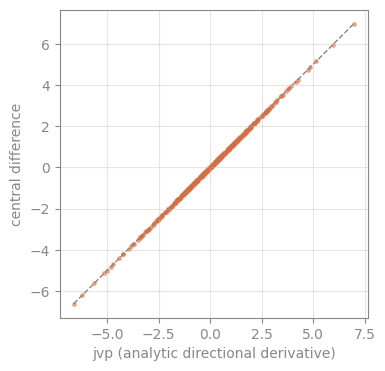

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
lo, hi = dot_out.min(), dot_out.max()
ax.plot([lo, hi], [lo, hi], color="#898781", lw=1, ls="--")
ax.scatter(dot_out, fd, s=6, color="#eb6834", alpha=0.5)
ax.set_xlabel("jvp (analytic directional derivative)"); ax.set_ylabel("central difference")
ax.set_aspect("equal"); ax.grid(alpha=0.4)
plt.show()

`dot_v` names the input tangent, `dot_out` the output tangent — the same
`dot_<name>` convention on every forward-mode kernel.

## A terminated sample's derivative is exactly zero

A kernel that reads `Terminated` only as a mask, never its own state
from before this launch, can still be differentiated — and a sample the
guard skips contributes **exactly** zero to the derived output, live
samples unaffected:

In [7]:
from hawk import Terminated


@hawk.kernel
def diagnostic(x: Scalar, terminated: Terminated, y: Mutable[Scalar]):
    y = x + 1.0


diagnostic_jvp = Kernel("diagnostic_jvp", jvp(diagnostic, wrt=("x",)))
diag_dir = pathlib.Path(tempfile.mkdtemp())
hawk.build([diagnostic, diagnostic_jvp], diag_dir, targets=("host",));


In [8]:
x = np.arange(8, dtype=float) + 1.0
terminated = np.zeros(8, dtype=bool)
terminated[4:] = True                 # the second half is already done
dot_x, dot_y = np.full(8, 0.4), np.zeros(8)
diag_jvp_host = hawk.load(diag_dir, "diagnostic_jvp")
hawk.run(diag_jvp_host, x=x, terminated=terminated, dot_x=dot_x, dot_y=dot_y)
print("dot_y (live samples keep dy/dx=1, terminated samples are exactly 0):", dot_y)


dot_y (live samples keep dy/dx=1, terminated samples are exactly 0): [0.4 0.4 0.4 0.4 0.  0.  0.  0. ]


## What hawk refuses outright

hawk keeps no tape *across launches*. A `Mutable` plane read before it
is written in the SAME body — its launch-start value, a running total
carried forward from the previous launch — is a recurrence the
differentiated launch alone cannot see the whole of, so `vjp`/`jvp`
refuse a kernel that reads one, by name, rather than silently returning
a derivative that is wrong for part of what the kernel computes:

In [9]:
from hawk.ir import HawkError
from hawk.diff import vjp


@hawk.kernel
def running_total(x: Scalar, terminated: Terminated, acc: Mutable[Scalar]):
    acc = acc + x   # reads acc's launch-start value -- a recurrence across launches


try:
    vjp(running_total)
except HawkError as exc:
    print("refused:", exc)

refused: 'acc' is read before it is assigned: a plane's launch-start value is a recurrence across launches; its derivative needs the value the primal launch overwrites, and hawk keeps no tape — differentiate the per-launch term instead


## What just happened

- `jvp(primal, wrt=...)` pushes one input tangent (`dot_<name>`) forward
  into one output tangent (`dot_<name>`) — the same derivation `vjp`
  uses, read the other way.
- A sample the `Terminated` guard skips gets an **exactly zero** derivative
  (reverse or forward); a live sample's derivative is unaffected.
- A kernel that reads a `Mutable` plane's launch-start value — a
  recurrence carried from the previous launch — refuses differentiation
  outright, naming the plane, rather than returning a derivative that is
  quietly wrong.

## Try this

Change `terminated[4:] = True` to `terminated[:] = True` and re-run: every
`dot_y` is exactly zero.

## Next

[Lookups, scatters and sums](06_lookups_scatters_and_sums) — read a table,
scatter into bins, and reduce a batch — the three plane kinds every
tutorial so far has skipped.